# Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from keras.layers import Activation,  Conv1D
from keras import initializers

2024-09-30 23:03:11.645012: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-30 23:03:11.645088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-30 23:03:11.647028: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-30 23:03:11.658400: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-30 23:03:13.274183: W tensorflow/compiler/tf2

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')  # Or 'ggplot', 'seaborn-dark', etc.

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': [6, 4],  # Aspect ratio
    'savefig.dpi': 300,  # High-resolution output
})
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)


<Figure size 600x400 with 0 Axes>

# Carga de Datos

In [3]:
porosity = np.load('porosity_data.npy')
seismic = np.load('seismic_data.npy')

In [4]:
porosity.shape, seismic.shape

((2500, 199), (2500, 246))

In [5]:
dt=7e-4
end_time=0.172
time_upscaled = np.arange(0, end_time, dt)
diffDepth = 1
depth = np.arange(1,porosity.shape[1]+1)*diffDepth

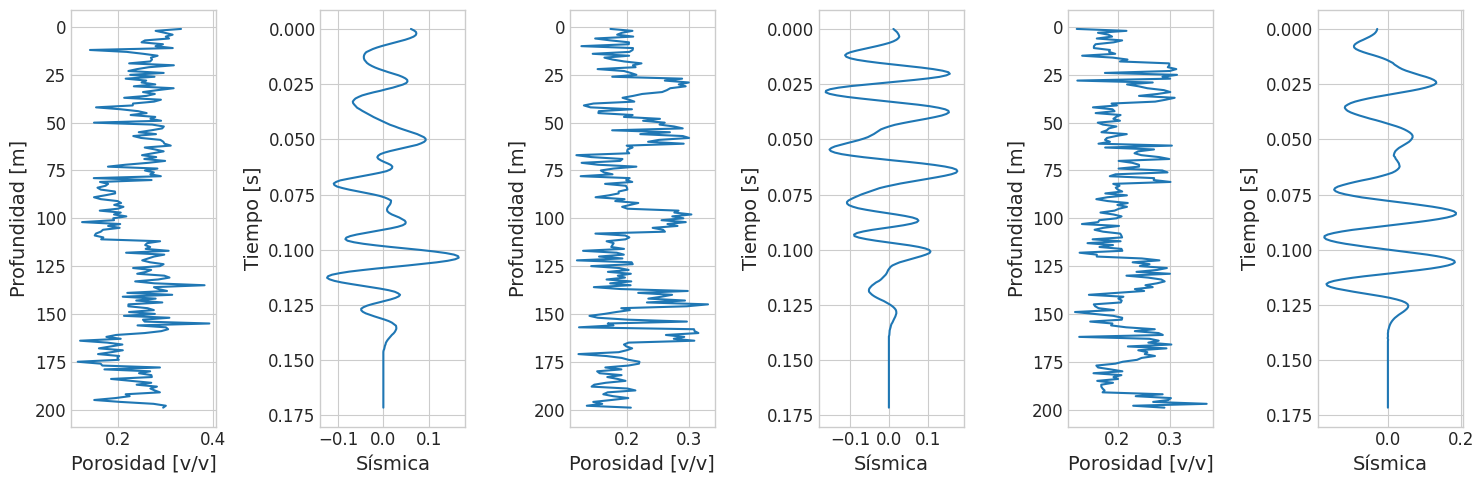

In [6]:
fig, ax = plt.subplots(1,6, figsize=(15,5))

ax[0].plot(np.squeeze(porosity[1,:]), depth)
ax[0].invert_yaxis()
ax[0].set_ylabel('Profundidad [m]')
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].plot(np.squeeze(seismic[1,:]), time_upscaled)
ax[1].invert_yaxis()
ax[1].set_ylabel('Tiempo [s]')
ax[1].set_xlabel('Sísmica')

ax[2].plot(np.squeeze(porosity[10,:]), depth)
ax[2].invert_yaxis()
ax[2].set_ylabel('Profundidad [m]')
ax[2].set_xlabel('Porosidad [v/v]')


ax[3].plot(np.squeeze(seismic[10,:]), time_upscaled)
ax[3].invert_yaxis()
ax[3].set_ylabel('Tiempo [s]')
ax[3].set_xlabel('Sísmica')

ax[4].plot(np.squeeze(porosity[100,:]), depth)
ax[4].invert_yaxis()
ax[4].set_ylabel('Profundidad [m]')
ax[4].set_xlabel('Porosidad [v/v]')


ax[5].plot(np.squeeze(seismic[100,:]), time_upscaled)
ax[5].invert_yaxis()
ax[5].set_ylabel('Tiempo [s]')
ax[5].set_xlabel('Sísmica')


#fig.suptitle('Porosidad vs Sísmica')
fig.tight_layout()
fig.savefig('plots/vashisth_example.png')



# Tratamiento de Datos
## Convertir Porosidad a Tiempo

In [7]:
Kg = 0.06
Kw = 2.61
RHOw = 1.01
RHOg = 0.18 
diffP = 16.5 
RHOs = 2.65
PhiC = 0.4 
Coordination = 14 
Fudge = 1
diffDepth = 20
vclay=tf.cast(0,tf.float64)
sw=tf.cast(1,tf.float64)
Kf = 1/(sw/Kw + (1 - sw)/Kg)
RHOf = sw*RHOw + (1 - sw) * RHOg


2024-09-30 23:03:17.510981: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-30 23:03:17.559680: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-30 23:03:17.559747: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-30 23:03:17.563014: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-30 23:03:17.563129: I external/local_xla/xla/stream_executor

In [8]:
def SoftSandNew(Kf,RHOf,Phi,Quartz,Clay,Feldspar,Limestone,Dolomite,Pressure,PhiC,Coordination,Fudge):
    # Uncemented sand rock physics model (modified to implement automatic-differentiation)
    #               INPUTS
    #
    #Kf				Fluid bulk modulus
    #RHOf			Fluid density
    #Phi			Porosity (fraction)
    #Quartz, etc.	Volume mineral content in solid phase (fraction)
    #Pressure		Effective pressure (MPa)
    #PhiC			Critical porosity ~0.4
    #Coordination	Coordination number ~6
    #Fudge			Reduction in shear stiffness -- 1 by default
    #
    #a is the contact radius between two spheres at input pressure

    #Balancing mineralogy
    Dolomite=1-(Quartz+Clay+Feldspar+Limestone)
    
    #Constants for clay
    RHOClay=2.65 
    KClay=21 
    GClay=7
    #Solid-phase elastic moduli
    KsV=Quartz*36.6+Clay*KClay+Limestone*76.8+Dolomite*94.9+Feldspar*75.6
    KsR=1/(Quartz/36.6+Clay/KClay+Limestone/76.8+Dolomite/94.9+Feldspar/75.6)
    Ks=0.5*(KsV+KsR)
    
    GsV=Quartz*45+Clay*GClay+Limestone*32+Dolomite*45+Feldspar*25.6
    GsR=1/(Quartz/45+Clay/GClay+Limestone/32+Dolomite/45+Feldspar/25.6)
    Gs=0.5*(GsV+GsR)
    Ms=Ks+(4/3)*Gs
    NUs=0.5*(Ms/Gs-2)/(Ms/Gs-1)
    
    #Solid-phase density
    RHOs=Quartz*2.65+Clay*RHOClay+Limestone*2.71+Dolomite*2.87+Feldspar*2.63
    
    #ILLITE
    #RHOs=2.58; Ms=RHOs.*4.32.*4.32; Gs=RHOs.*2.54.*2.54; NUs=0.5*(Ms./Gs-2)./(Ms./Gs-1); Ks=Ms-(4/3)*Gs;
    
    P=Pressure/1000
    C=Coordination
    
    #================== Dry Rock ====================
    #Effective K and G at PhiC
    #Hertz contact radius (R=1)
    a=tf.pow(((3*3.14*(1-NUs)/(2*C*(1-PhiC)*Gs))*P),(1/3))
    #Normal contact stiffness
    SN=4*a*Gs/(1-NUs)
    #Shear contact stiffness
    ST=8*a*Gs/(2-NUs)
    #Shear contact stiffness FUDGED (reduced)
    ST=ST/Fudge
    
    #Bulk modulus
    Khat=C*(1.-PhiC)*SN/(12*3.14)
    #Shear modulus
    Ghat=C*(1.-PhiC)*(SN+1.5*ST)/(20*3.14)
    
    #Effective bulk and shear moduli at porosity Phi<=PhiC
    KDry1=1/((Phi/PhiC)/(Khat+4*Ghat/3)+((PhiC-Phi)/PhiC)/(Ks+4*Ghat/3))-4*Ghat/3
    ZZ1=(Ghat/6)*(9*Khat+8*Ghat)/(Khat+2*Ghat)
    GDry1=1/((Phi/PhiC)/(Ghat+ZZ1)+((PhiC-Phi)/PhiC)/(Gs+ZZ1))-ZZ1
    MDry1 = KDry1+(4/3)*GDry1
    NuDry1=0.5*(MDry1/GDry1-2)/(MDry1/GDry1-1)
    
    #Effective bulk and shear moduli at porosity Phi>PhiC
    KDry2 = 1/(((1-Phi)/(1-PhiC))/(Khat+4*Ghat/3)+((Phi-PhiC)/(1-PhiC))/(4*Ghat/3))-4*Ghat/3
    ZZ2 = (Ghat/6)*(9*Khat+8*Ghat)/(Khat+2*Ghat)
    GDry2 = 1/(((1-Phi)/(1-PhiC))/(Ghat+ZZ2)+((Phi-PhiC)/(1-PhiC))/(ZZ2))-ZZ2
    MDry2 = KDry2+(4/3)*GDry2
    NuDry2=0.5*(MDry2/GDry2-2)/(MDry2/GDry2-1)
    
    MDry=MDry1*(tf.cast((Phi<=PhiC), tf.float64))+MDry2*(tf.cast((Phi>PhiC), tf.float64)) 
    GDry=GDry1*(tf.cast((Phi<=PhiC), tf.float64))+GDry2*(tf.cast((Phi>PhiC), tf.float64))
    NuDry=NuDry1*(tf.cast((Phi<=PhiC), tf.float64))+NuDry2*(tf.cast((Phi>PhiC), tf.float64))
    KDry=MDry-(4/3)*GDry
    
    # ================== Saturated Rock ============
    KSat=Ks*(Phi*KDry-(1+Phi)*Kf*KDry/Ks+Kf)/((1-Phi)*Kf+Phi*Ks-Kf*KDry/Ks)
    MSat=KSat+(4/3)*GDry
    RHOB=(1-Phi)*RHOs+Phi*RHOf
    Vp=tf.pow((MSat/RHOB),0.5)
    Vs=tf.pow((GDry/RHOB),0.5)
    Ip=Vp*RHOB
    PR=0.5*(MSat/GDry-2)/(MSat/GDry-1)
    
    return Vp,Vs,RHOB

In [9]:
def DecoderLinearInterpLayer(x,xp,fp):
    i = tf.clip_by_value(tf.searchsorted(xp, x, side='right'), 1, xp.shape[1] - 1)

    fp1=tf.gather(fp,indices=i-1, batch_dims=1)
    fp2=tf.gather(fp,indices=i, batch_dims=1)
    xp1=tf.gather(xp,indices=i-1, batch_dims=1)
    xp2=tf.gather(xp,indices=i, batch_dims=1)

    f = (fp1 *  (xp2 - x) + fp2 * (x - xp1)) / (xp2 - xp1)

    left=fp[0,0]
    right = fp[-1,-1]

    ff = tf.where(x < tf.ones_like(x)*tf.expand_dims(xp[:,0],axis=1), left, f)
    fff = tf.where(x > tf.ones_like(x)*tf.expand_dims(xp[:,-1],axis=1), tf.ones_like(x)*tf.expand_dims(fp[:,-1],axis=1), ff)
    return fff

In [10]:
Vp_final,Vs_final,RHO_final=SoftSandNew(Kf,RHOf,porosity,(1 - vclay)*0.8,vclay, (1 - vclay)*0.2,0,0,diffP, PhiC, Coordination, Fudge)

depth_diff = np.mean(np.diff(depth.T))
time0=0.0/(Vp_final[:,0])
time1 = 2*tf.cumsum(depth_diff/(Vp_final*1e3),axis=1)
time_final = tf.concat([tf.expand_dims(time0, axis=1),time1],axis=1)
time = time_final[:,0:-1]

time_new=tf.ones_like(time, dtype=tf.float64)
for i in range(len(time_upscaled)-time.shape[1]):
    time_new=tf.concat([time_new,tf.expand_dims(time0+1.0,axis=1)],axis=1)
pred_t=time_new*time_upscaled

Phi_time=DecoderLinearInterpLayer(pred_t,time,porosity)
RHO_time=DecoderLinearInterpLayer(pred_t,time,RHO_final)


2024-09-30 23:03:18.266198: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


## Primera Visualización de Datos

In [11]:
seed_og = 318 #np.random.randint(0,2500)
trace_porosity = Phi_time[seed_og,:]
trace_seismic = seismic[seed_og,:]
seed_og

318

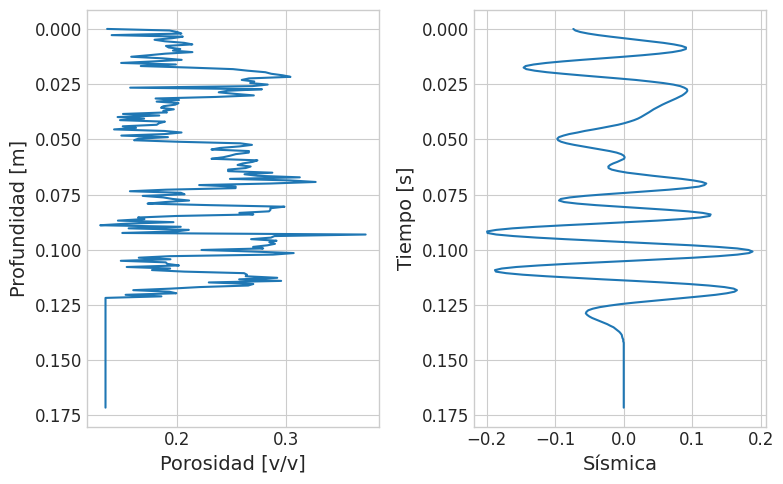

In [12]:
fig, ax = plt.subplots(1,2, figsize=(8,5))

ax[0].plot(np.squeeze(trace_porosity), time_upscaled)
ax[0].invert_yaxis()
ax[0].set_ylabel('Profundidad [m]')
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].plot(np.squeeze(trace_seismic), time_upscaled)
ax[1].invert_yaxis()
ax[1].set_ylabel('Tiempo [s]')
ax[1].set_xlabel('Sísmica')

fig.tight_layout()

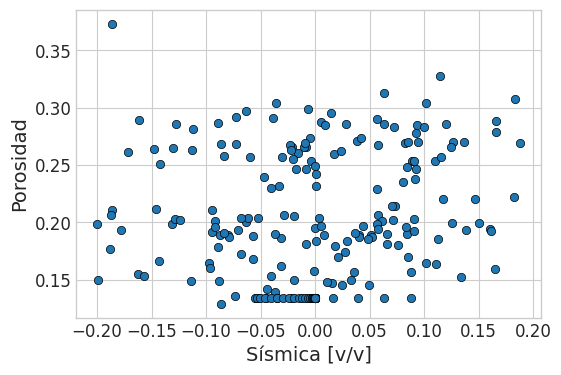

In [13]:
fig, ax = plt.subplots(1,1)

ax.scatter(trace_seismic, trace_porosity, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Sísmica [v/v]')
ax.set_ylabel('Porosidad')
#fig.suptitle(f'Porosidad vs Sísmica en traza: {seed}')

fig.savefig('plots/vashisth_crossplot_correlation.png')

In [14]:
phi_time_numpy = Phi_time.numpy()

## Normalización de Datos

In [15]:
def min_max_scale(x, min, max):

  x_std = (x - min) / (max - min)
  x_scaled = x_std * 2 - 1
  return x_scaled

def inverse_min_max_scale(x, min, max):

  x_normalized = (x + 1) / 2
  x_unscaled = x_normalized * (max - min) + min
  return x_unscaled

### Porosidad

In [16]:
phi_max=np.max(phi_time_numpy)
phi_min=np.min(phi_time_numpy)

In [17]:
phi_scaled = min_max_scale(phi_time_numpy, min= phi_min, max=phi_max)
phi_unscaled = inverse_min_max_scale(phi_scaled, min= phi_min, max=phi_max)

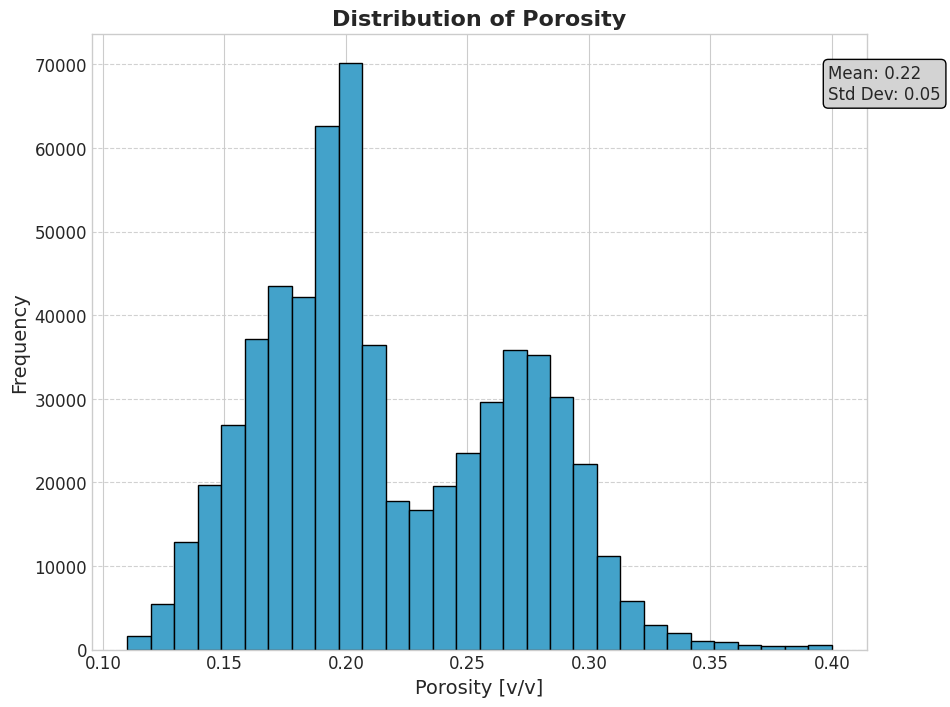

In [18]:
plt.figure(figsize=(10, 8))
plt.hist(phi_time_numpy.ravel(), bins=30, edgecolor='black', color='#43a2ca')
# Add titles and labels
plt.title('Distribution of Porosity', fontsize=16, fontweight='bold')
plt.xlabel('Porosity [v/v]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a text box annotation
textstr = 'Mean: {:.2f}\nStd Dev: {:.2f}'.format(np.mean(phi_time_numpy.ravel()), np.std(phi_time_numpy.ravel()))
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='lightgray'))

# Show plot
#plt.savefig('./plots/unnormalized_porosity_distribution.png')
plt.show()

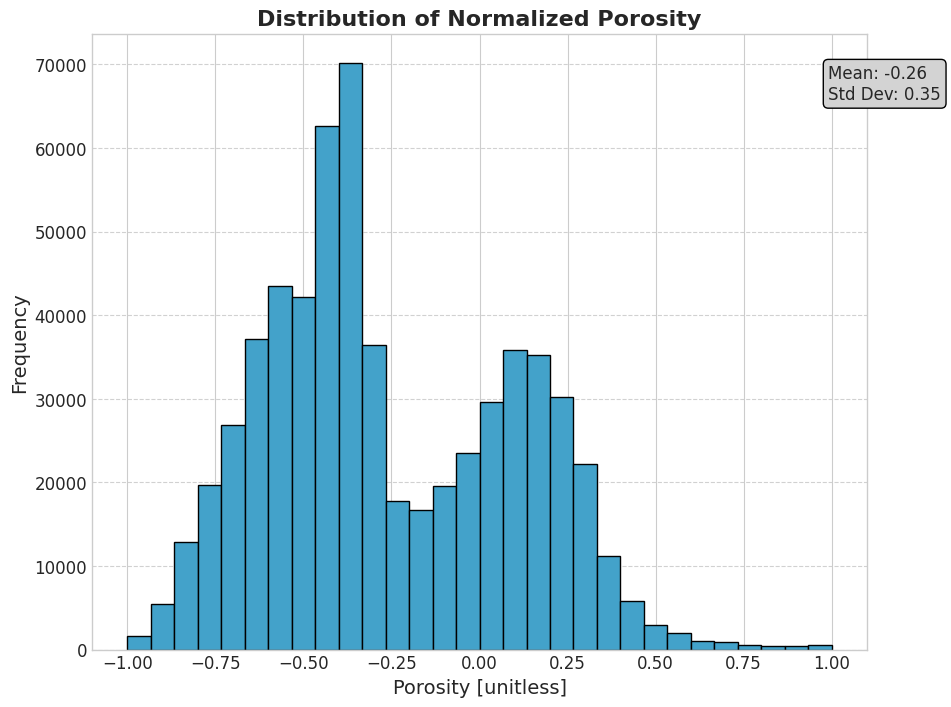

In [19]:
plt.figure(figsize=(10, 8))
plt.hist(phi_scaled.ravel(), bins=30, edgecolor='black', color='#43a2ca')
# Add titles and labels
plt.title('Distribution of Normalized Porosity', fontsize=16, fontweight='bold')
plt.xlabel('Porosity [unitless]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a text box annotation
textstr = 'Mean: {:.2f}\nStd Dev: {:.2f}'.format(np.mean(phi_scaled.ravel()), np.std(phi_scaled.ravel()))
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='lightgray'))

# Show plot
#plt.savefig('./plots/unnormalized_porosity_distribution.png')
plt.show()

### Sísmica

In [20]:
# Normalizing the input and output data  

seis_normalized = (seismic - np.min(seismic))/(np.max(seismic)-np.min(seismic))

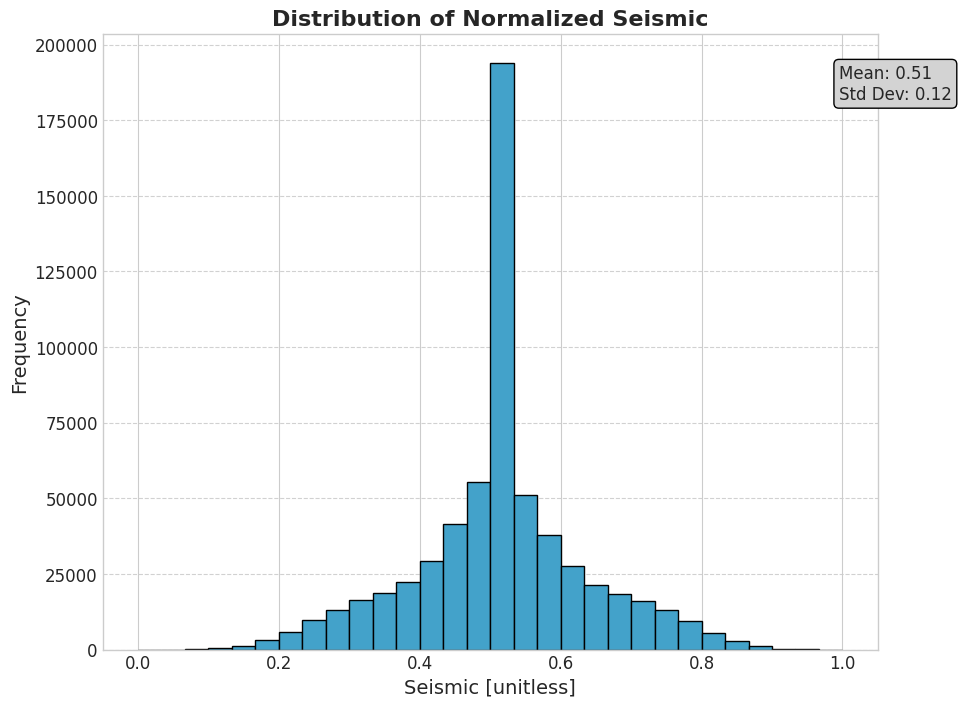

In [21]:
plt.figure(figsize=(10, 8))
plt.hist(seis_normalized.ravel(), bins=30, edgecolor='black', color='#43a2ca')
# Add titles and labels
plt.title('Distribution of Normalized Seismic', fontsize=16, fontweight='bold')
plt.xlabel('Seismic [unitless]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a text box annotation
textstr = 'Mean: {:.2f}\nStd Dev: {:.2f}'.format(np.mean(seis_normalized.ravel()), np.std(seis_normalized.ravel()))
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='lightgray'))

# Show plot
plt.savefig('./plots/normalized_seismic_distribution.png')
plt.show()

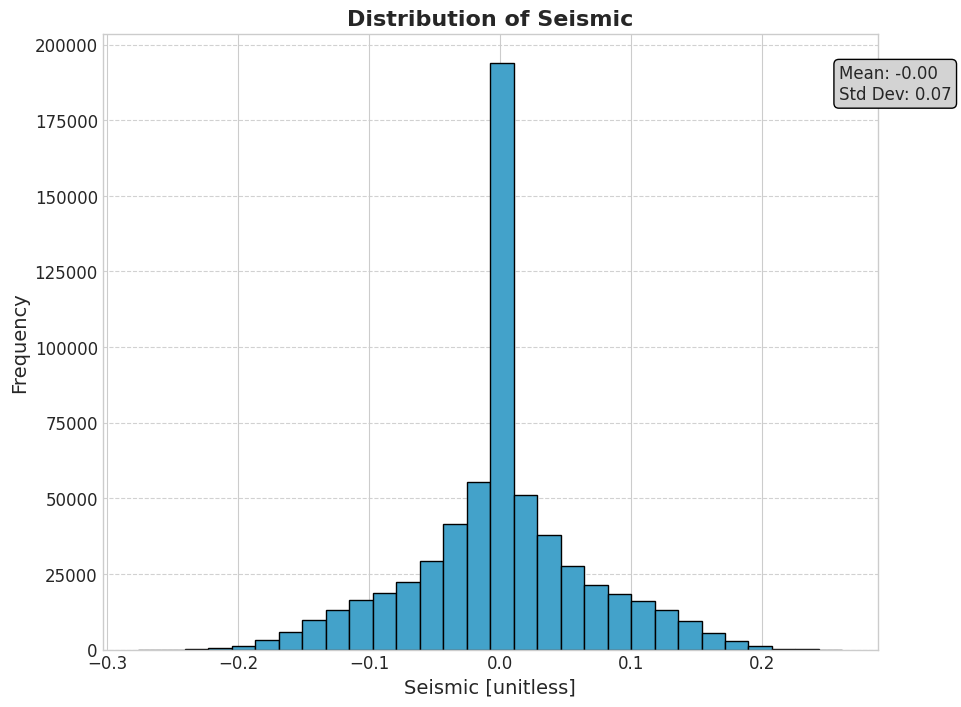

In [22]:
plt.figure(figsize=(10, 8))
plt.hist(seismic.ravel(), bins=30, edgecolor='black', color='#43a2ca')
# Add titles and labels
plt.title('Distribution of Seismic', fontsize=16, fontweight='bold')
plt.xlabel('Seismic [unitless]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a text box annotation
textstr = 'Mean: {:.2f}\nStd Dev: {:.2f}'.format(np.mean(seismic.ravel()), np.std(seismic.ravel()))
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='lightgray'))

# Show plot
plt.savefig('./plots/seismic_distribution.png')
plt.show()

In [23]:
np.min(seis_normalized), np.max(seis_normalized)

(0.0, 1.0)

In [24]:
np.min(phi_scaled), np.max(phi_scaled)

(-1.0, 1.0)

In [25]:
seismic.shape, phi_scaled.shape

((2500, 246), (2500, 246))

## Creacion de Train y Test

In [26]:
X_train_norm = seis_normalized[:1750, :]
y_train_norm = phi_scaled[:1750, :]
X_test_norm = seis_normalized[1750:, :]
y_test_norm = phi_scaled[1750:, :]

In [27]:
X_train = seismic[:1750, :]
y_train = phi_time_numpy[:1750, :]
X_test = seismic[1750:, :]
y_test = phi_time_numpy[1750:, :]

In [28]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1675, 246), (825, 246), (1675, 246), (825, 246))

### Reshape

Este reshape se le hace para entrenar en los algoritmos como DecisionTree, XGBoost y MLP usando todos los datos 

In [29]:
X_train_reshaped = X_train.reshape(-1,1)
X_test_reshaped = X_test.reshape(-1,1)

y_train_reshaped = y_train.reshape(-1,1)
y_test_reshaped = y_test.reshape(-1,1)

In [30]:
X_train_reshaped.shape, X_test_reshaped.shape, y_train_reshaped.shape, y_test_reshaped.shape

((412050, 1), (202950, 1), (412050, 1), (202950, 1))

# Machine Learning

## Regresión Lineal

In [31]:
lin_reg = LinearRegression().fit(trace_seismic.reshape(-1,1), trace_porosity)

In [32]:
y_pred_linear = lin_reg.predict(trace_seismic.reshape(-1,1))

In [33]:
line_x = np.array([-0.2, 0.2])
line_y = lin_reg.predict(line_x.reshape(-1,1))

### Metricas

In [34]:
rmse_rl = np.sqrt(mean_squared_error(trace_porosity, y_pred_linear))
MAE_rl = mean_absolute_error(trace_porosity, y_pred_linear)
r2_rl = r2_score(trace_porosity, y_pred_linear)

print("RMSE : % f" %(rmse_rl))
print("MAE : % f" %(MAE_rl))
print("R2 : % f" %(r2_rl))

RMSE :  0.056798
MAE :  0.048656
R2 :  0.014859


In [35]:
print(f'y = {lin_reg.coef_[0]:3.3}x + {lin_reg.intercept_:3.3}')

y = 0.0883x + 0.196


### Graficado

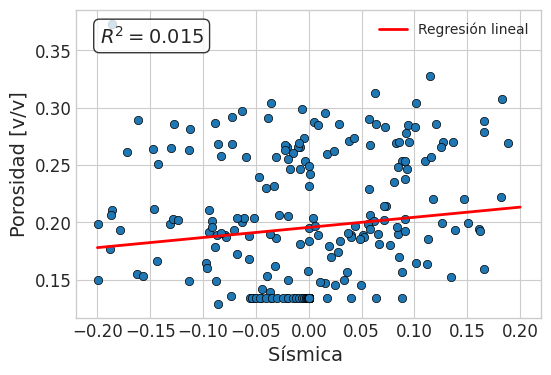

In [36]:
fig, ax = plt.subplots(1,1)

ax.scatter(trace_seismic, trace_porosity, edgecolor='black', linewidth=0.5)
ax.plot(line_x, line_y, color='red', linewidth=2, label='Regresión lineal')
# Agregar la caja de texto con el valor de R²
textstr = rf"$R^2 = {r2_rl:.3f}$"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

# Agregar la leyenda
legend = ax.legend(loc='upper right', fontsize='small')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)

ax.set_xlabel('Sísmica ')
ax.set_ylabel('Porosidad [v/v]')
#fig.suptitle(f'Porosidad vs Sísmica en traza: {seed}')

fig.savefig('plots/vashisth_crossplot_regression.png')

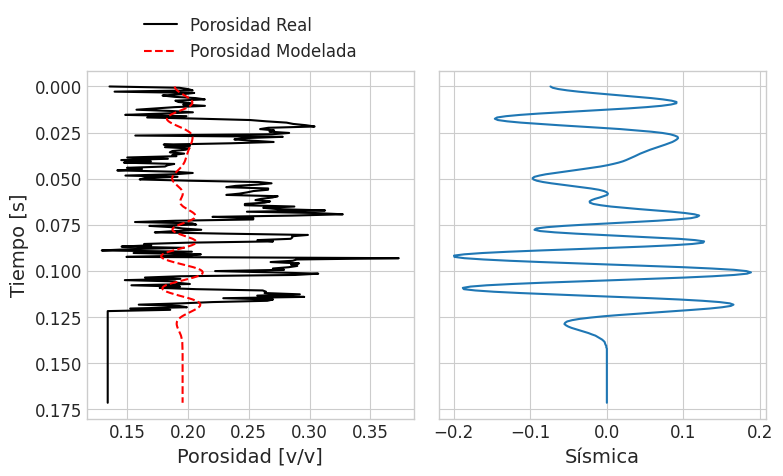

In [37]:
fig, ax = plt.subplots(1,2, figsize=(8,5), sharey=True)

ax[0].plot(np.squeeze(trace_porosity), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_linear), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')
ax[0].set_ylabel('Tiempo [s]')


ax[1].plot(np.squeeze(trace_seismic), time_upscaled)
ax[1].set_xlabel('Sísmica')

ax[0].legend(loc='upper center',    bbox_to_anchor=(0.5, 1.2),  # 0.5 es el centro del eje x, 1.15 está ligeramente por encima del gráfico
)
#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
fig.tight_layout()
fig.savefig('plots/resultado_regresion_lineal_seccion.png')

## Regresión Cuadrática o Cúbica

In [38]:
from sklearn.preprocessing import PolynomialFeatures

In [39]:
poly = PolynomialFeatures(degree=2, include_bias=False)

In [40]:
poly_features = poly.fit_transform(trace_seismic.reshape(-1, 1))
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, trace_porosity)

LinearRegression()

### Metricas

In [41]:
y_predicted_quadratic = poly_reg_model.predict(poly_features)

In [42]:
rmse_quadratic = np.sqrt(mean_squared_error(trace_porosity, y_predicted_quadratic))
MAE_quadratic = mean_absolute_error(trace_porosity, y_predicted_quadratic)
r2_quadratic = r2_score(trace_porosity, y_predicted_quadratic)

print("RMSE : % f" %(rmse_quadratic))
print("MAE : % f" %(MAE_quadratic))
print("R2 : % f" %(r2_quadratic))

RMSE :  0.053588
MAE :  0.045643
R2 :  0.123069


### Graficado

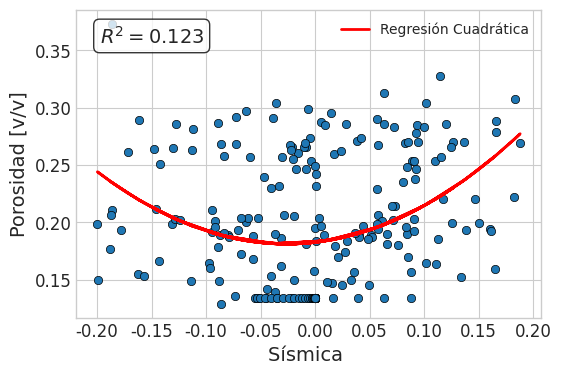

In [43]:
fig, ax = plt.subplots(1,1)

ax.scatter(trace_seismic, trace_porosity, edgecolor='black', linewidth=0.5)
ax.plot(trace_seismic, y_predicted_quadratic, color='red', linewidth=2, label='Regresión Cuadrática')
# Agregar la caja de texto con el valor de R²
textstr = rf"$R^2 = {r2_quadratic:.3f}$"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

# Agregar la leyenda
legend = ax.legend(loc='upper right', fontsize='small')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)

ax.set_xlabel('Sísmica ')
ax.set_ylabel('Porosidad [v/v]')
#fig.suptitle(f'Porosidad vs Sísmica en traza: {seed}')
# Formatear los ticks para mostrar solo 2 decimales
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

fig.savefig('plots/vashisth_crossplot_quadratic.png')

## Arboles de Decisión

### Prueba con 1 pozo

In [44]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import tree

In [45]:
dtr = DecisionTreeRegressor()
dtr_controled = DecisionTreeRegressor(min_samples_leaf=10)

In [46]:
dtr.fit(trace_seismic.reshape(-1, 1), trace_porosity)
dtr_controled.fit(trace_seismic.reshape(-1, 1), trace_porosity)

DecisionTreeRegressor(min_samples_leaf=10)

In [47]:
y_pred_tree_dtr_train = dtr.predict(trace_seismic.reshape(-1, 1))

In [48]:
rmse_dtr_train = np.sqrt(mean_squared_error(trace_porosity, y_pred_tree_dtr_train))
MAE_dtr_train = mean_absolute_error(trace_porosity, y_pred_tree_dtr_train)
r2_dtr_train = r2_score(trace_porosity, y_pred_tree_dtr_train)

print("RMSE : % f" %(rmse_dtr_train))
print("MAE : % f" %(MAE_dtr_train))
print("R2 : % f" %(r2_dtr_train))

RMSE :  0.000000
MAE :  0.000000
R2 :  1.000000


#### Metricas - Blind Test

In [49]:
seed_test = 1409 #np.random.randint(0,2500)
trace_porosity_test = Phi_time[seed_test,:]
trace_seismic_test = seismic[seed_test,:]
seed_test

1409

In [50]:
y_pred_tree_test = dtr.predict(trace_seismic_test.reshape(-1, 1))
y_pred_tree_test_controled = dtr_controled.predict(trace_seismic_test.reshape(-1, 1))

In [51]:
rmse_dtr_test_1well = np.sqrt(mean_squared_error(trace_porosity_test, y_pred_tree_test))
MAE_dtr_test_1well = mean_absolute_error(trace_porosity_test, y_pred_tree_test)
r2_dtr_test_1well = r2_score(trace_porosity_test, y_pred_tree_test)

print("RMSE : % f" %(rmse_dtr_test_1well))
print("MAE : % f" %(MAE_dtr_test_1well))
print("R2 : % f" %(r2_dtr_test_1well))

RMSE :  0.069135
MAE :  0.057458
R2 : -1.261063


In [52]:
rmse_dtr_test_1well_depth5 = np.sqrt(mean_squared_error(trace_porosity_test, y_pred_tree_test_controled))
mae_dtr_test_1well_depth5 = mean_absolute_error(trace_porosity_test, y_pred_tree_test_controled)
r2_dtr_test_1well_depth5 = r2_score(trace_porosity_test, y_pred_tree_test_controled)

print("RMSE : % f" %(rmse_dtr_test_1well_depth5))
print("MAE : % f" %(mae_dtr_test_1well_depth5))
print("R2 : % f" %(r2_dtr_test_1well_depth5))

RMSE :  0.055650
MAE :  0.049030
R2 : -0.465076


#### Graficado

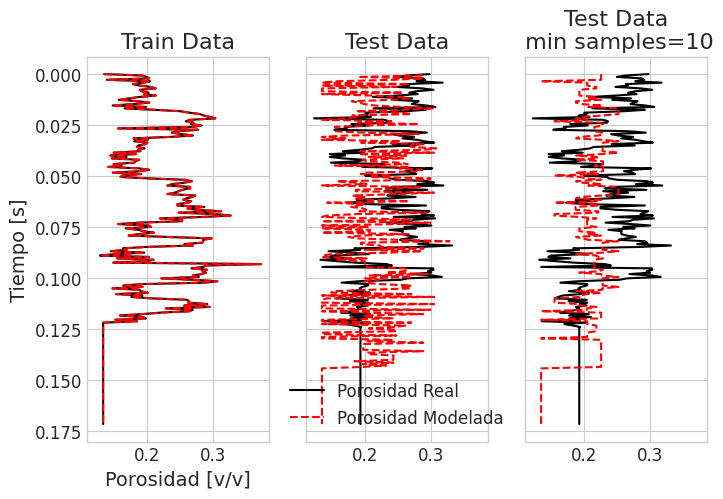

In [53]:
fig, ax = plt.subplots(1,3, figsize=(8,5), sharey=True, sharex=True)

ax[0].plot(np.squeeze(trace_porosity), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_tree_dtr_train), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')
ax[0].set_ylabel('Tiempo [s]')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')
ax[0].set_title('Train Data')


ax[1].plot(np.squeeze(trace_porosity_test), time_upscaled, label='Porosidad Real', color='black')
ax[1].plot(np.squeeze(y_pred_tree_test), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')
ax[1].set_title('Test Data')


ax[2].plot(np.squeeze(trace_porosity_test), time_upscaled, label='Porosidad Real', color='black')
ax[2].plot(np.squeeze(y_pred_tree_test_controled), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')
ax[2].set_title('Test Data\n min samples=10')


#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
ax[1].legend(loc='lower center')
#fig.tight_layout()
fig.savefig('plots/resultado_arboles_de_decision_1_pozo.png')

In [54]:
# Obtener los parámetros y metadatos
params = dtr.get_params()
max_depth = dtr.get_depth()
n_leaves = dtr.get_n_leaves()

print("Parámetros del modelo:", params)
print("Profundidad máxima alcanzada:", max_depth)
print("Número de hojas:", n_leaves)

Parámetros del modelo: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Profundidad máxima alcanzada: 16
Número de hojas: 193


In [55]:
# Obtener los parámetros y metadatos
params = dtr_controled.get_params()
max_depth = dtr_controled.get_depth()
n_leaves = dtr_controled.get_n_leaves()

print("Parámetros del modelo:", params)
print("Profundidad máxima alcanzada:", max_depth)
print("Número de hojas:", n_leaves)

Parámetros del modelo: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Profundidad máxima alcanzada: 6
Número de hojas: 16


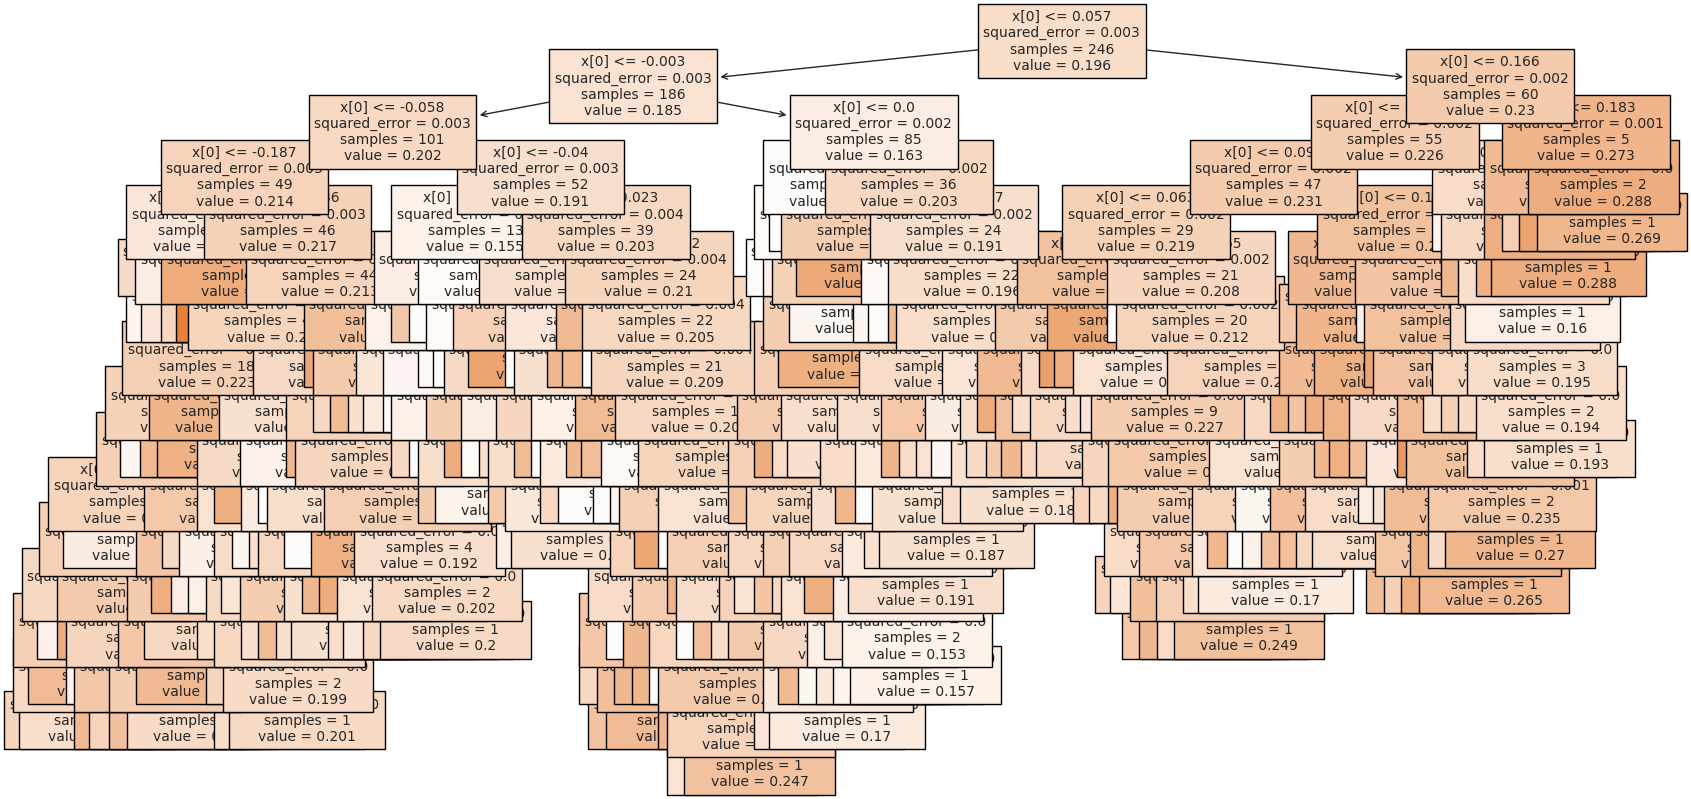

In [56]:
# Crear la figura con un tamaño grande
plt.figure(figsize=(20, 10))  # Ajusta el tamaño según tus necesidades
plot_tree(dtr, filled=True, fontsize=10)

# Guardar la figura con alta resolución
plt.savefig('plots/decision_tree.png', dpi=300)
plt.show()


### Prueba con todo el dataset

In [57]:
dtr_full = DecisionTreeRegressor()
dtr_full.fit(X_train_reshaped, y_train_reshaped)

DecisionTreeRegressor()

In [58]:
y_pred_train = dtr_full.predict(X_train_reshaped)
y_pred_test = dtr_full.predict(X_test_reshaped)

#### Metricas

In [59]:
rmse_dtr_train = np.sqrt(mean_squared_error(y_train_reshaped, y_pred_train))
MAE_dtr_train = mean_absolute_error(y_train_reshaped, y_pred_train)
r2_dtr_train = r2_score(y_train_reshaped, y_pred_train)

print("RMSE : % f" %(rmse_dtr_train))
print("MAE : % f" %(MAE_dtr_train))
print("R2 : % f" %(r2_dtr_train))

RMSE :  0.028196
MAE :  0.014003
R2 :  0.694454


In [60]:
rmse_dtr_test = np.sqrt(mean_squared_error(y_test_reshaped, y_pred_test))
MAE_dtr_test = mean_absolute_error(y_test_reshaped, y_pred_test)
r2_dtr_test = r2_score(y_test_reshaped, y_pred_test)

print("RMSE : % f" %(rmse_dtr_test))
print("MAE : % f" %(MAE_dtr_test))
print("R2 : % f" %(r2_dtr_test))

RMSE :  0.066206
MAE :  0.053020
R2 : -0.690128


#### Graficado

In [61]:
y_pred_train_reshaped = y_pred_train.reshape(1675, 246)
y_pred_test_reshaped = y_pred_test.reshape(825, 246)

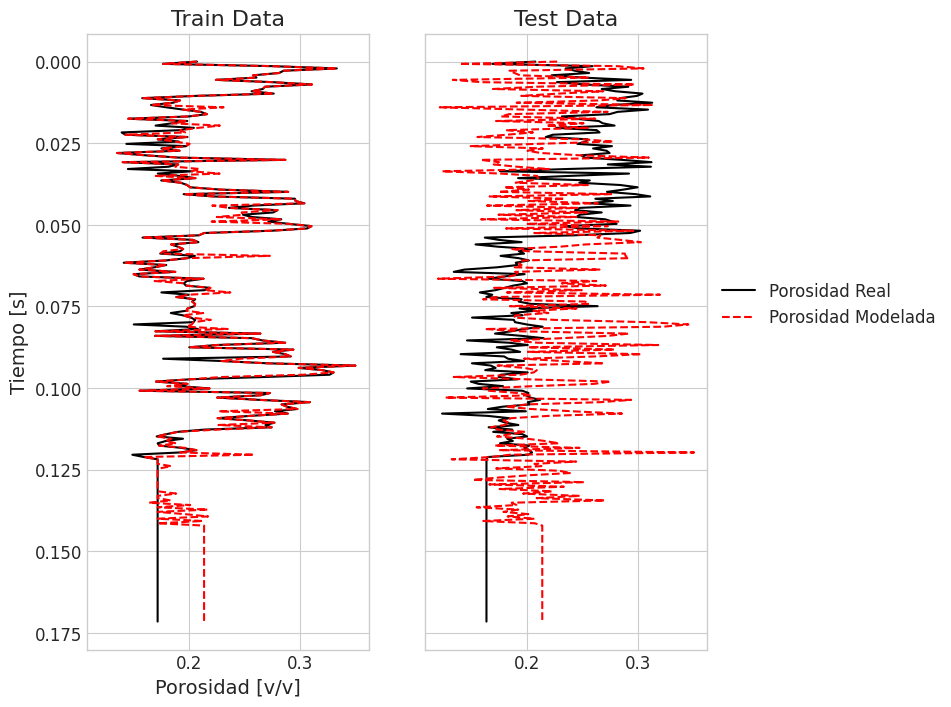

In [62]:
fig, ax = plt.subplots(1,2, figsize=(8,8), sharey=True, sharex=True)

ax[0].set_title('Train Data')
ax[0].plot(np.squeeze(y_train[354,:]), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_train_reshaped[354,:]), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')
ax[0].set_ylabel('Tiempo [s]')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].set_title('Test Data')
ax[1].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Porosidad Real', color='black')
ax[1].plot(np.squeeze(y_pred_test_reshaped[256,:]), time_upscaled, label='Porosidad Modelada', linestyle='--', color='red')



#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
ax[1].legend(loc='lower left',bbox_to_anchor=(1, 0.5))
#fig.tight_layout()
fig.savefig('plots/resultado_arboles_de_decision_todo.png')

In [63]:
# Obtener los parámetros y metadatos
params = dtr_full.get_params()
max_depth = dtr_full.get_depth()
n_leaves = dtr_full.get_n_leaves()

print("Parámetros del modelo:", params)
print("Profundidad máxima alcanzada:", max_depth)
print("Número de hojas:", n_leaves)

Parámetros del modelo: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Profundidad máxima alcanzada: 188
Número de hojas: 290756


## XGBoost

In [64]:
import xgboost as xg 
from sklearn.model_selection import RandomizedSearchCV


In [65]:
xgb_r = xg.XGBRegressor(seed=123)

param_dist = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500, 1000],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'booster': ['gbtree', 'dart']
}

random_search = RandomizedSearchCV(estimator=xgb_r, param_distributions=param_dist, scoring='neg_mean_squared_error', n_iter=10, cv=3, verbose=1)



In [66]:
xgb_r.fit(X_train_reshaped, y_train_reshaped)
# Get the best parameters
#best_params = random_search.best_params_
#print("Best parameters:", best_params)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [67]:
pred_xgboost = xgb_r.predict(X_test_reshaped)

### Metricas

In [68]:
# RMSE Computation 
rmse_xgboost = np.sqrt(mean_squared_error(y_test_reshaped, pred_xgboost)) 
mae_xgboost = mean_absolute_error(y_test_reshaped, pred_xgboost)
r2_xgboost = r2_score(y_test_reshaped, pred_xgboost)

print("RMSE : % f" %(rmse_xgboost))
print("MAE : % f" %(mae_xgboost))
print("R2 : % f" %(r2_xgboost))

RMSE :  0.050358
MAE :  0.042596
R2 :  0.022178


### Graficado

In [69]:
y_pred_xgboost_reshaped = pred_xgboost.reshape(825, 246)

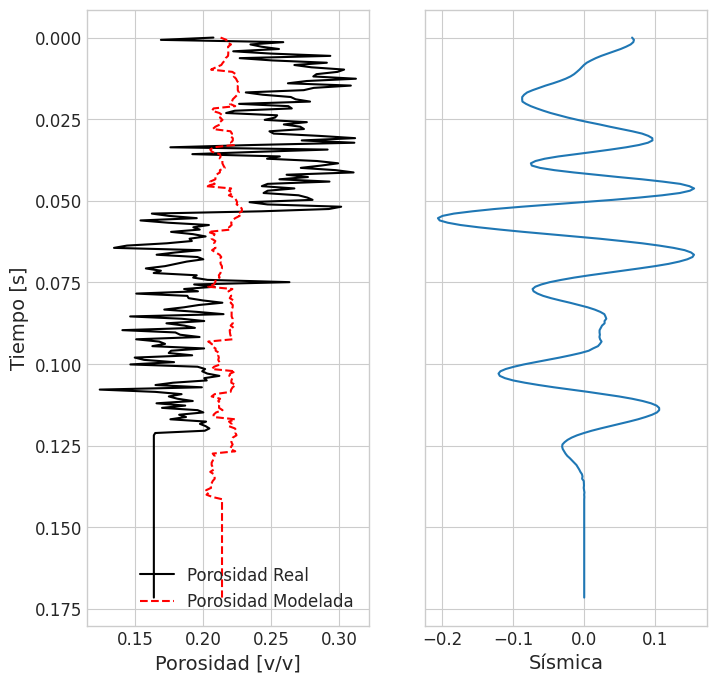

In [70]:
fig, ax = plt.subplots(1,2, figsize=(8,8), sharey=True)

ax[0].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_xgboost_reshaped[256,:]), time_upscaled, label='Porosidad Modelada', color='red', linestyle='--')
ax[0].set_ylabel('Tiempo [s]')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].plot(np.squeeze(X_test[500,:]), time_upscaled)
ax[1].set_xlabel('Sísmica')


#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
ax[0].legend(loc='lower right')
#fig.tight_layout()
#fig.savefig('plots/resultado_regresion_lineal_seccion.png')

## Red Neuronal 

In [71]:
from sklearn.neural_network import MLPRegressor

In [72]:
mlp = MLPRegressor(random_state=1, max_iter=100, hidden_layer_sizes=(500, 500), activation='tanh')
mlp = mlp.fit(X_train, y_train)

In [73]:
mlp.n_layers_

4

In [74]:
y_pred_mlp = mlp.predict(X_test)

### Metricas

In [75]:
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
MAE_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("RMSE : % f" %(rmse_mlp))
print("MAE : % f" %(MAE_mlp))
print("R2 : % f" %(r2_mlp))

RMSE :  0.032513
MAE :  0.025387
R2 :  0.582610


### Graficado

In [76]:
y_pred_mlp_reshaped = y_pred_mlp.reshape(825,246)

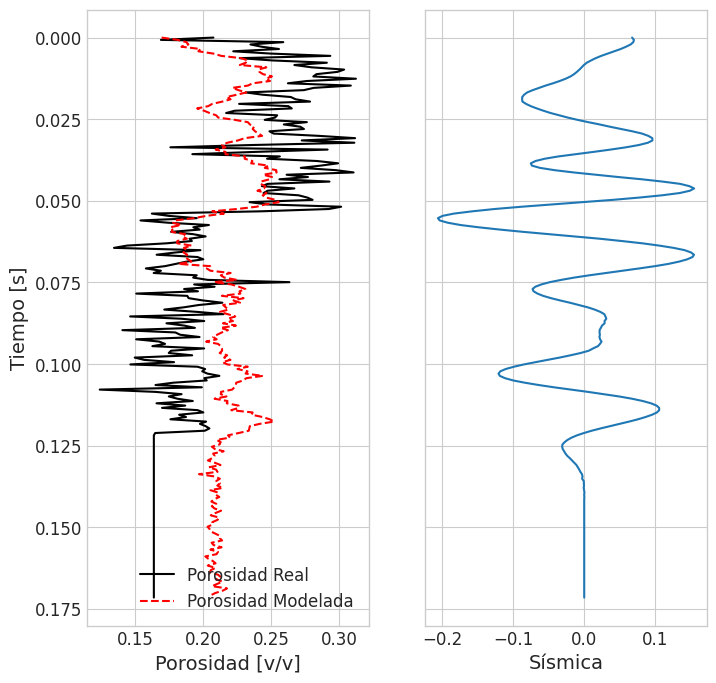

In [77]:
fig, ax = plt.subplots(1,2, figsize=(8,8), sharey=True)

ax[0].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_mlp_reshaped[256,:]), time_upscaled, label='Porosidad Modelada', color='red', linestyle='--')
ax[0].set_ylabel('Tiempo [s]')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].plot(np.squeeze(X_test[500,:]), time_upscaled)
ax[1].set_xlabel('Sísmica')


#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
ax[0].legend(loc='lower right')
#fig.tight_layout()
fig.savefig('plots/resultado_mlp_seccion.png')

Text(0.5, 1.0, 'Función de Pérdida')

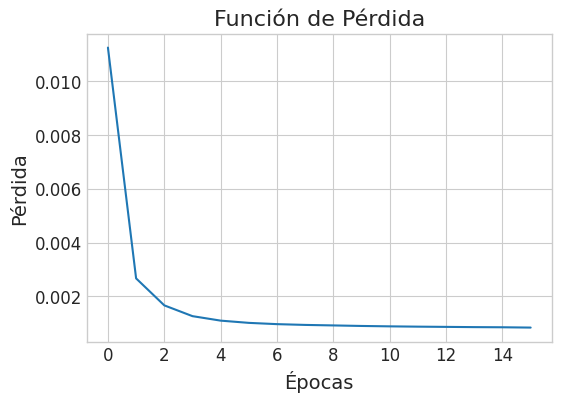

In [78]:
plt.plot(range(0,len(mlp.loss_curve_)), mlp.loss_curve_)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Función de Pérdida')

## Red Neuronal Convolucional (CNN)

In [79]:
X_train_final_cnn = np.expand_dims(X_train_norm, axis=1)
X_test_final_cnn = np.expand_dims(X_test_norm, axis=1)

### Arquitectura

In [80]:
given_seed=2

def naive_model():
    """El input shape de tal forma sería entonces (1, 246) ya que son trazas sismicas, 2000 de ellas"""

    model = tf.keras.models.Sequential()
        #probar a poner capa densa al comienzo y luego pasar por la convolución
    input_final = tf.keras.Input(shape=(X_train_final_cnn.shape[1:]))
    model.add(input_final)
    #model.add(tf.keras.layers.Reshape((-1,1)))
    
    model.add(Conv1D(filters=128, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=256, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=512, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=1024, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    model.add(tf.keras.layers.Dropout(rate=0.3))
    

    model.add(tf.keras.layers.Flatten())
 
    
    model.add(tf.keras.layers.Dense(units=246,kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros'))
    model.add(Activation('tanh'))

    return model
    

model_phi = naive_model()
model_phi.build((None,246,1))
model_phi.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1, 128)            94592     
                                                                 
 activation (Activation)     (None, 1, 128)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 1, 256)            98560     
                                                                 
 activation_1 (Activation)   (None, 1, 256)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 1, 512)            393728    
                                                                 
 activation_2 (Activation)   (None, 1, 512)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 1, 1024)           1

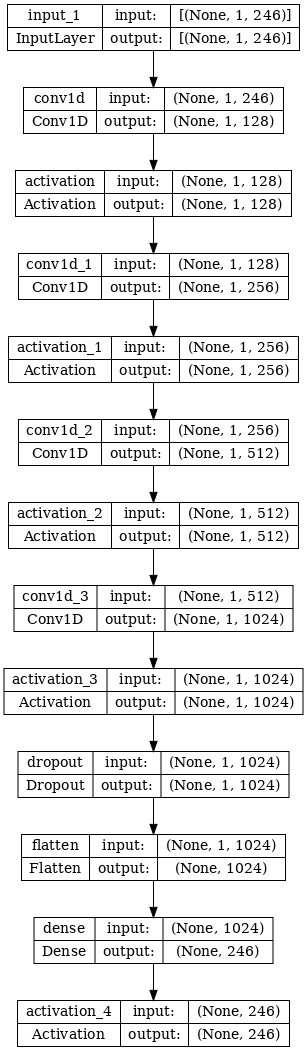

In [81]:
tf.keras.utils.plot_model(model_phi, show_shapes=True, dpi=72, to_file='model.png')

In [82]:
def r2_nicolas(Y_val_final, phi_pred):
    sum_squares_residuals = tf.reduce_sum((Y_val_final - phi_pred) ** 2)
    sum_squares = tf.reduce_sum((Y_val_final - tf.reduce_mean(Y_val_final)) ** 2)
    R2 = 1 - sum_squares_residuals / sum_squares
    return R2

In [83]:
optimizer = tf.keras.optimizers.Adam()

model_phi.compile(optimizer=optimizer,
                    loss='mse',
                    metrics=r2_nicolas)

In [84]:
#callback_early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, mode='auto')
checkpoint = tf.keras.callbacks.ModelCheckpoint('model_naive.h5', 
                                                monitor='val_r2_nicolas', 
                                                mode='max', 
                                                verbose=1, 
                                                save_weights_only=True)

callback_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='r2_nicolas', 
                                                   factor=0.5, 
                                                   patience=50, 
                                                   min_lr=0.000001)

### Entrenamiento

In [85]:
epocas=100

In [86]:
history_early = model_phi.fit(x=X_train_final_cnn, 
                                y=y_train_norm,
                                epochs=epocas,
                                batch_size=10,
                                callbacks=[checkpoint, callback_lr]                         
                                )

Epoch 1/100


2024-09-30 23:04:08.815782: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-09-30 23:04:09.065762: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-09-30 23:04:10.201441: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f77ec512bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-09-30 23:04:10.201489: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2024-09-30 23:04:10.207732: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1727755450.340486   32744 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


168/168 [==============================] - ETA: 0s - loss: 0.1073 - r2_nicolas: 0.1171
Epoch 1: saving model to model_naive.h5
168/168 [==============================] - 6s 15ms/step - loss: 0.1073 - r2_nicolas: 0.1171 - lr: 0.0010
Epoch 2/100
167/168 [============================>.] - ETA: 0s - loss: 0.0868 - r2_nicolas: 0.2834
Epoch 2: saving model to model_naive.h5
168/168 [==============================] - 2s 11ms/step - loss: 0.0868 - r2_nicolas: 0.2841 - lr: 0.0010
Epoch 3/100
168/168 [==============================] - ETA: 0s - loss: 0.0827 - r2_nicolas: 0.3147
Epoch 3: saving model to model_naive.h5
168/168 [==============================] - 2s 11ms/step - loss: 0.0827 - r2_nicolas: 0.3147 - lr: 0.0010
Epoch 4/100
168/168 [==============================] - ETA: 0s - loss: 0.0792 - r2_nicolas: 0.3471
Epoch 4: saving model to model_naive.h5
168/168 [==============================] - 2s 11ms/step - loss: 0.0792 - r2_nicolas: 0.3471 - lr: 0.0010
Epoch 5/100
164/168 [===============

### Métricas

In [87]:
loss, accuracy = model_phi.evaluate(X_test_final_cnn, y_test_norm)

26/26 [==============================] - 1s 19ms/step - loss: 0.0477 - r2_nicolas: 0.6102


In [88]:
y_pred_cnn = model_phi.predict(X_test_final_cnn)

26/26 [==============================] - 0s 3ms/step


In [89]:
y_pred_cnn = inverse_min_max_scale(y_pred_cnn, phi_min, phi_max)

In [90]:
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
MAE_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print("RMSE : % f" %(rmse_mlp))
print("MAE : % f" %(MAE_mlp))
print("R2 : % f" %(r2_mlp))

RMSE :  0.032513
MAE :  0.025387
R2 :  0.582610


### Graficado

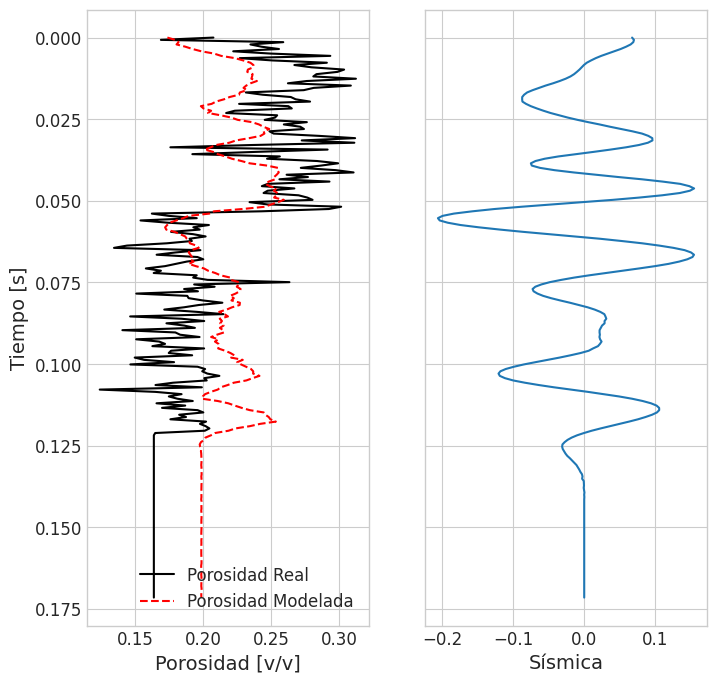

In [91]:
fig, ax = plt.subplots(1,2, figsize=(8,8), sharey=True)

ax[0].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Porosidad Real', color='black')
ax[0].plot(np.squeeze(y_pred_cnn[256,:]), time_upscaled, label='Porosidad Modelada', color='red', linestyle='--')
ax[0].set_ylabel('Tiempo [s]')
ax[0].invert_yaxis()
ax[0].set_xlabel('Porosidad [v/v]')


ax[1].plot(np.squeeze(X_test[500,:]), time_upscaled)
ax[1].set_xlabel('Sísmica')


#fig.suptitle('Comparacion entre porosidad modelada y real', y=0.9)
ax[0].legend(loc='lower right')
#fig.tight_layout()
fig.savefig('plots/resultado_cnn_seccion.png')

# Final Results

In [92]:
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.fancybox'] = False  # Disable rounded corners
plt.rcParams['legend.borderaxespad'] = 0.5  # Adjust if needed

In [93]:
y_predict_linear = lin_reg.predict(X_test[256,:].reshape(-1,1))

poly_features_final = poly.fit_transform(X_test[256,:].reshape(-1, 1))
y_predict_quadratic = poly_reg_model.predict(poly_features)

y_predict_tree = dtr.predict(X_test[256,:].reshape(-1, 1))

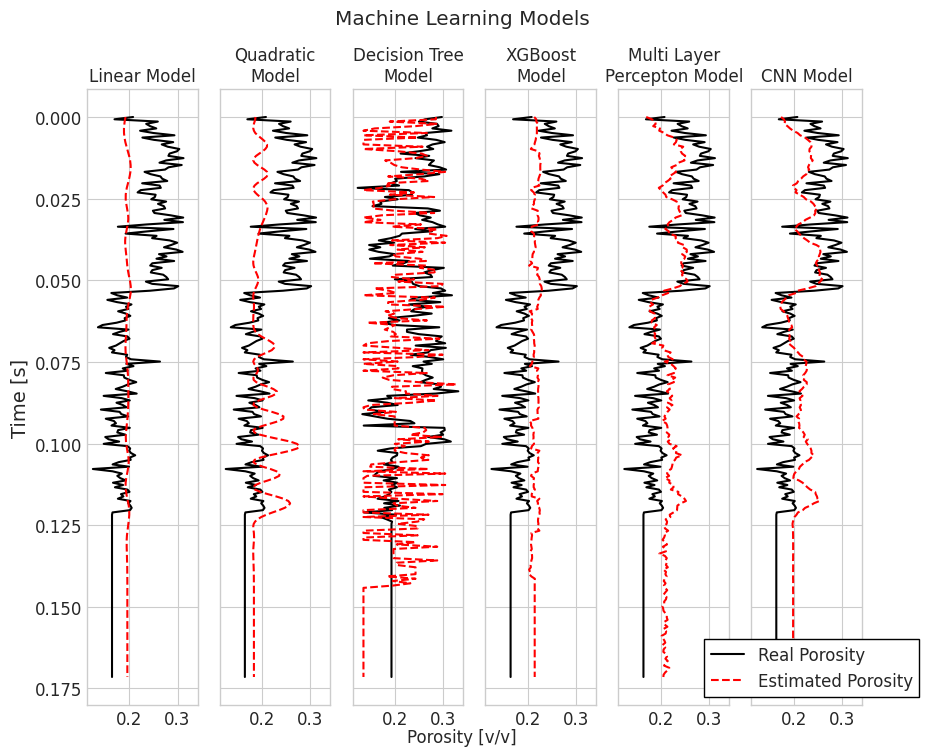

In [94]:
fig, ax = plt.subplots(1,6, figsize=(10,8), sharey=True, sharex=True)

ax[0].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Real Porosity', color='black')
ax[0].plot(np.squeeze(y_predict_linear), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[0].set_ylabel('Time [s]')
ax[0].invert_yaxis()
ax[0].set_title('Linear Model', fontsize=12)

ax[1].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Real Porosity', color='black')
ax[1].plot(np.squeeze(y_predict_quadratic), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[1].set_title('Quadratic\nModel', fontsize=12)

ax[2].plot(np.squeeze(trace_porosity_test), time_upscaled, label='Real Porosity', color='black')
ax[2].plot(np.squeeze(y_pred_tree_test), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[2].set_title('Decision Tree\nModel', fontsize=12)


ax[3].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Real Porosity', color='black')
ax[3].plot(np.squeeze(y_pred_xgboost_reshaped[256,:]), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[3].set_title('XGBoost\nModel', fontsize=12)

ax[4].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Real Porosity', color='black')
ax[4].plot(np.squeeze(y_pred_mlp_reshaped[256,:]), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[4].set_title('Multi Layer\nPercepton Model', fontsize=12)

ax[5].plot(np.squeeze(y_test[256,:]), time_upscaled, label='Real Porosity', color='black')
ax[5].plot(np.squeeze(y_pred_cnn[256,:]), time_upscaled, label='Estimated Porosity', color='red', linestyle='--')
ax[5].set_title('CNN Model', fontsize=12)

fig.suptitle('Machine Learning Models')
fig.text(0.5, 0.07, 'Porosity [v/v]', ha='center', va='center')

# Customize the legend
legend = ax[5].legend(loc='lower left', bbox_to_anchor=(-0.5, 0))
legend.get_frame().set_facecolor('white')  # Set background to white
legend.get_frame().set_alpha(1)  # Remove transparency
legend.get_frame().set_edgecolor('black')  # Set edge color to black
legend.get_frame().set_linewidth(1)  # Set line width to 1

plt.show()
fig.savefig('plots/resultado_compilado.png')

# Table

In [95]:
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
MAE_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)


In [96]:
metodo = {'Method': ['Linear Regression', 'Quadratic Regression', 'Decision Tree', 'Decision Tree (Full Dataset)', 'XGBoost', 'Multilayer Perceptron', 'Convolutional Neural Network'],
            'Determination Coefficient':[r2_rl, r2_quadratic, r2_dtr_test_1well, r2_dtr_test, r2_xgboost, r2_mlp, r2_cnn],
            'MSE':[rmse_rl, rmse_quadratic, rmse_dtr_test_1well, rmse_dtr_test, rmse_xgboost, rmse_mlp, rmse_cnn],
            'MAE':[MAE_rl, MAE_quadratic, MAE_dtr_test_1well, MAE_dtr_test, mae_xgboost, MAE_mlp, MAE_cnn]
          }

df_ml_techniques = pd.DataFrame(data=metodo)
df_ml_techniques

,Method,Determination Coefficient,MSE,MAE
0,Linear Regression,0.014859,0.056798,0.048656
1,Quadratic Regression,0.123069,0.053588,0.045643
2,Decision Tree,-1.261063,0.069135,0.057458
3,Decision Tree (Full Dataset),-0.690128,0.066206,0.053020
4,XGBoost,0.022178,0.050358,0.042596
5,Multilayer Perceptron,0.582610,0.032513,0.025387
6,Convolutional Neural Network,0.604664,0.031666,0.024493


In [97]:
# Convertir el DataFrame a formato LaTeX
latex_table = df_ml_techniques.to_latex(index=False)

# Mostrar la tabla en formato LaTeX
print(latex_table)

\begin{tabular}{lrrr}
\toprule
Method & Determination Coefficient & MSE & MAE \\
\midrule
Linear Regression & 0.014859 & 0.056798 & 0.048656 \\
Quadratic Regression & 0.123069 & 0.053588 & 0.045643 \\
Decision Tree & -1.261063 & 0.069135 & 0.057458 \\
Decision Tree (Full Dataset) & -0.690128 & 0.066206 & 0.053020 \\
XGBoost & 0.022178 & 0.050358 & 0.042596 \\
Multilayer Perceptron & 0.582610 & 0.032513 & 0.025387 \\
Convolutional Neural Network & 0.604664 & 0.031666 & 0.024493 \\
\bottomrule
\end{tabular}

